# Notebook 3 — Scoring & Results

Imputes missing values, reshapes data, computes the composite Education Potential Score (0–100) for each country, and identifies the top 20 markets for Academy's expansion.

**Input:** `data/processed/consolidated_table.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pycountry
import os

pd.set_option('display.max_columns', None)

# Find data directory (works from project root or notebooks/)
if os.path.isdir('data'):
    drive_data_path = os.path.abspath('data')
elif os.path.isdir('../data'):
    drive_data_path = os.path.abspath('../data')
else:
    raise FileNotFoundError('Cannot find data directory')

outputs_path = os.path.join(os.path.dirname(drive_data_path), 'outputs')
processed_path = os.path.join(drive_data_path, 'processed')
os.makedirs(processed_path, exist_ok=True)

os.chdir(drive_data_path)
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load consolidated table from Notebook 2
consolidated_table = pd.read_parquet(os.path.join(processed_path, 'consolidated_table.parquet'))
print(f'consolidated_table: {consolidated_table.shape}')
consolidated_table.head()

consolidated_table: (1720, 19)


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Remove indicators identified as redundant from correlation analysis
indicators_to_remove = [
    'Enrolment in secondary general, both sexes (number)',
    'Government expenditure per secondary student (US$)'
]

consolidated_table = consolidated_table[
    ~consolidated_table['Indicator Name'].isin(indicators_to_remove)
].copy()

print(f'Shape after removal: {consolidated_table.shape}')
consolidated_table.head()

Shape after removal: (1290, 19)

,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,AFG,Government expenditure per tertiary student (US$),UIS.XUNIT.US.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Processing 7: Indicator Selection and Missing Value Treatment

After removing correlated indicators, we:
1. **Visualise** the remaining missing values using `missingno`
2. **Impute** missing values per country and indicator using interpolation (forward and backward fill)
3. **Drop** rows where all year values remain missing (countries with no data at all for an indicator)

Missing values before imputation:


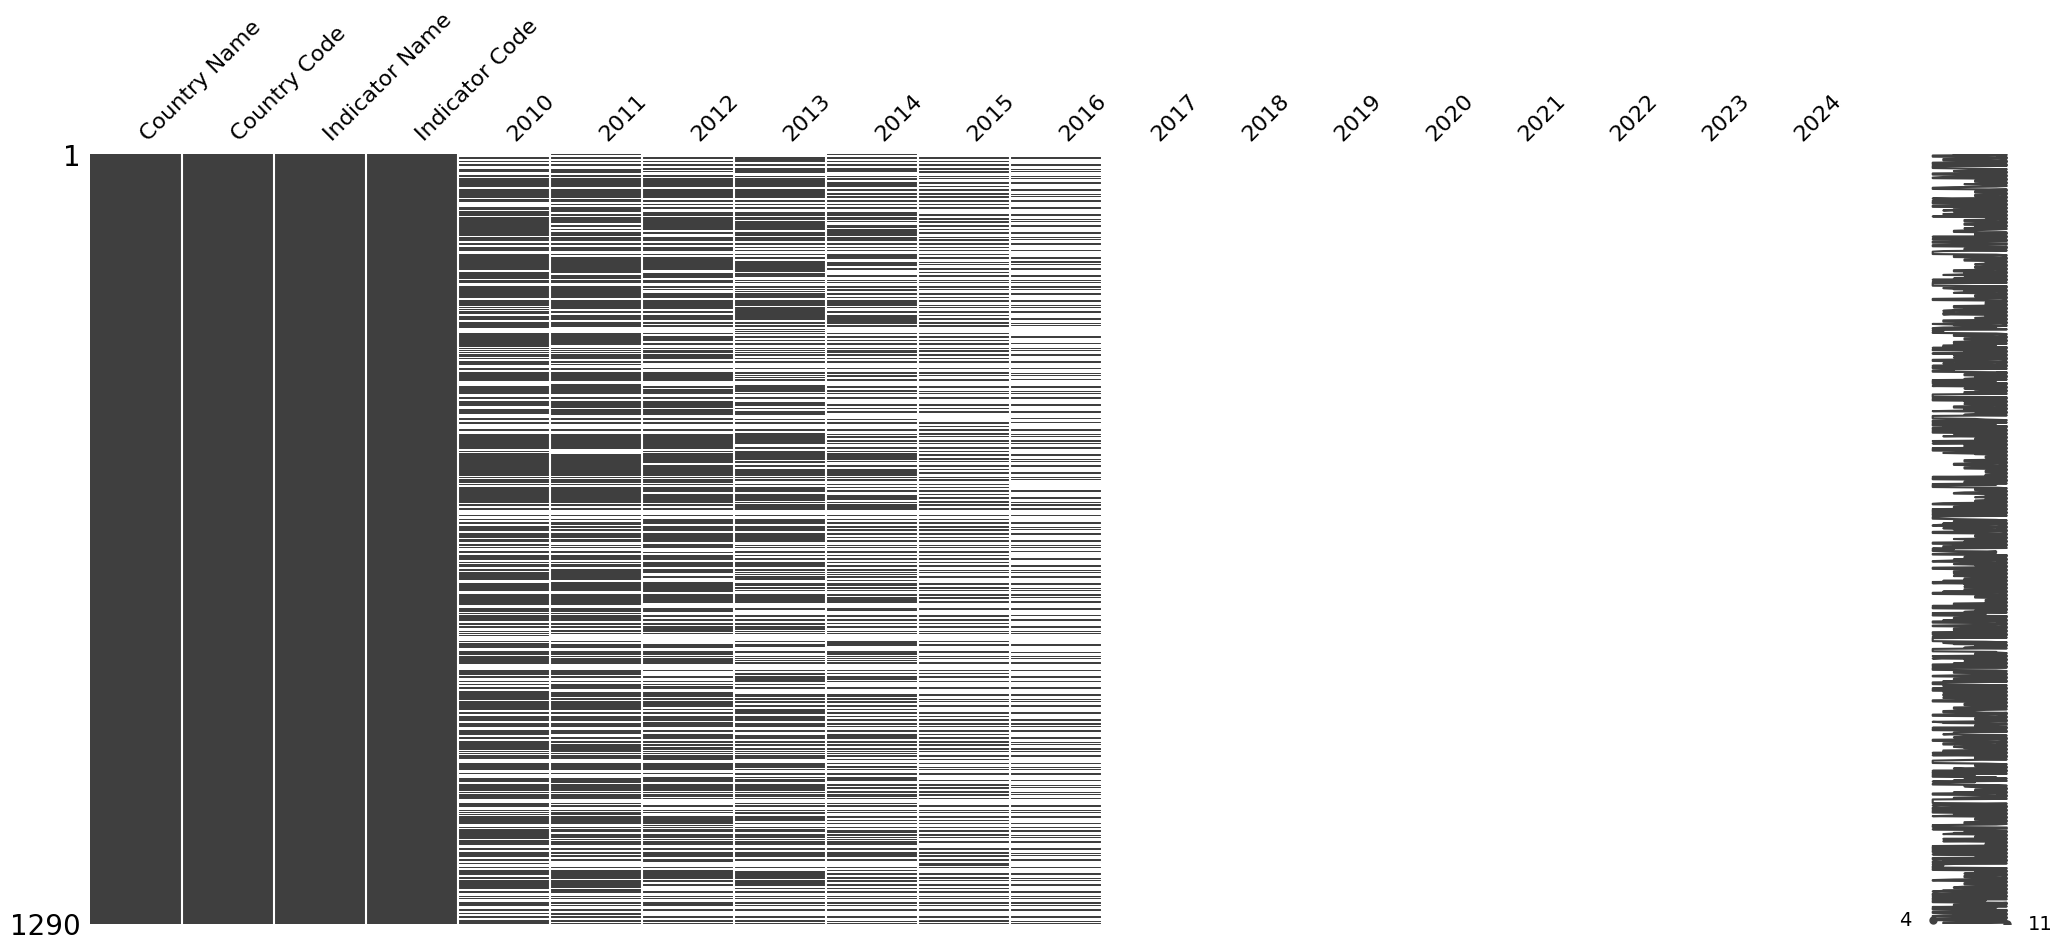

Missing values after imputation:


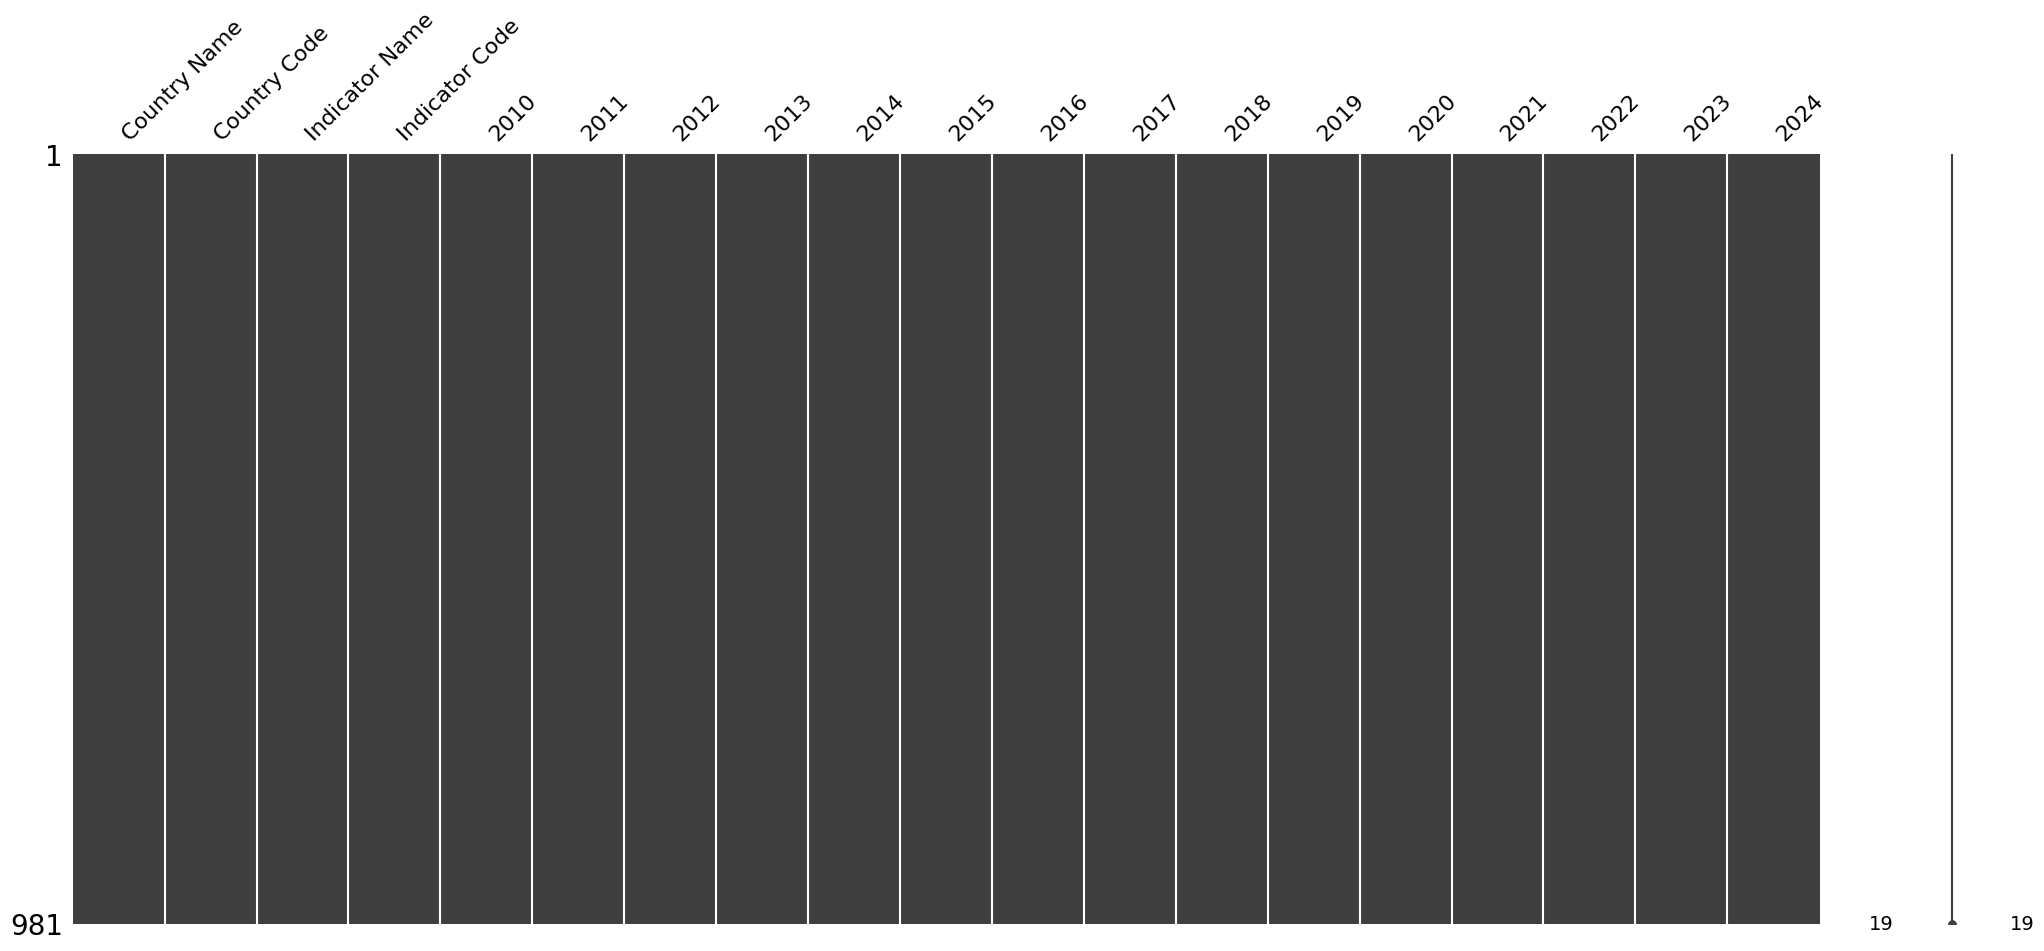

,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,9.750400e+04,9.750400e+04,1.526273e+05,2.077507e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05
2,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10
7,Afghanistan,AFG,Internet users (per 100 people),IT.NET.USER.P2,4.000000e+00,5.000000e+00,5.454545e+00,5.900000e+00,7.000000e+00,8.260000e+00,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01
9,Albania,ALB,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,1.223260e+05,1.348770e+05,1.608390e+05,1.730290e+05,1.738190e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05
10,Albania,ALB,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.192695e+10,1.289087e+10,1.231978e+10,1.277628e+10,1.322824e+10,1.133526e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10


In [4]:
print("Missing values before imputation:")
msno.matrix(consolidated_table)
plt.show()

# Interpolate missing values row-wise (each row = one country-indicator pair)
year_cols = [str(y) for y in range(2010, 2025)]

consolidated_table[year_cols] = (
    consolidated_table[year_cols]
    .interpolate(axis=1, limit_direction='both')
    .ffill(axis=1)
    .bfill(axis=1)
)
consolidated_table.dropna(subset=year_cols, how='all', inplace=True)

print("Missing values after imputation:")
msno.matrix(consolidated_table)
plt.show()

consolidated_table.head()

## Processing 8: Melting and Reshaping

Transform the consolidated table from **wide format** (year columns) to **long format** (Year/Value columns), then pivot so each indicator becomes its own column. This creates the final `reshaped_table` used for score computation.

Resulting columns: `Country Name`, `Country Code`, `Year`, and one column per indicator.

In [5]:
# Melt the consolidated table to long format
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Assuming these are the relevant year columns
)

# Pivot the table to have years in rows and indicators in columns
reshaped_table = melted_consolidated_table.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Indicator Name',
    values='Value'
).reset_index()

# Display the reshaped table
display(reshaped_table.head())

Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people)
0,Afghanistan,AFG,2010,97504.000000,1.593680e+10,NaN,NaN,NaN,4.000000
1,Afghanistan,AFG,2011,97504.000000,1.793024e+10,NaN,NaN,NaN,5.000000
2,Afghanistan,AFG,2012,152627.333333,2.053654e+10,NaN,NaN,NaN,5.454545
3,Afghanistan,AFG,2013,207750.666667,2.004633e+10,NaN,NaN,NaN,5.900000
4,Afghanistan,AFG,2014,262874.000000,2.005019e+10,NaN,NaN,NaN,7.000000


In [6]:
# Check for missing values in the reshaped table
missing_values_reshaped = reshaped_table.isna().mean().sort_values(ascending=False)

print("Percentage of Missing Values in the Reshaped Table:")
display(missing_values_reshaped)

Percentage of Missing Values in the Reshaped Table:


Indicator Name
Government expenditure per tertiary student (US$)                       0.431925
Government expenditure on tertiary education as % of GDP (%)            0.356808
Government expenditure on secondary education as % of GDP (%)           0.323944
Enrolment in tertiary education, all programmes, both sexes (number)    0.192488
GDP at market prices (current US$)                                      0.046948
Internet users (per 100 people)                                         0.042254
Country Name                                                            0.000000
Country Code                                                            0.000000
Year                                                                    0.000000
dtype: float64

## Processing 9: Education Potential Score

Compute a composite **Education Potential Score** (0Ã¢â‚¬â€œ100) for each country and year:

1. **Calculation 1**: Tertiary enrolment Ãƒâ€” Government expenditure per tertiary student
2. **Calculation 2**: GDP Ãƒâ€” (Secondary education % of GDP + Tertiary education % of GDP)
3. **Average** of both calculations (only when both are available)
4. **Normalise** using MinMaxScaler
5. **Weighted score**: 85% education spending + 15% internet access
6. Scale to 0Ã¢â‚¬â€œ100

In [7]:
# Calculate Education Expenditure using Formula 1
# Enrolment in tertiary education Ã— Government expenditure per tertiary student
reshaped_table['Education Expenditure (Calculation 1)'] = (
    reshaped_table['Enrolment in tertiary education, all programmes, both sexes (number)'] *
    reshaped_table['Government expenditure per tertiary student (US$)']
)

# Calculate Education Expenditure using Formula 2
# GDP Ã— (secondary education % of GDP + tertiary education % of GDP)
reshaped_table['Education Expenditure (Calculation 2)'] = (
    reshaped_table['GDP at market prices (current US$)'] *
    ((reshaped_table['Government expenditure on secondary education as % of GDP (%)'] / 100) +
     (reshaped_table['Government expenditure on tertiary education as % of GDP (%)'] / 100))
)

# Average of both calculations (only when both are available)
reshaped_table['Average Education Expenditure'] = reshaped_table.apply(
    lambda row: (row['Education Expenditure (Calculation 1)'] + row['Education Expenditure (Calculation 2)']) / 2
    if pd.notna(row['Education Expenditure (Calculation 1)']) and pd.notna(row['Education Expenditure (Calculation 2)'])
    else np.nan,
    axis=1
)

# Normalize and compute Education Potential Score
potential_indicators = [
    'Average Education Expenditure',
    'Internet users (per 100 people)'
]

scaler = MinMaxScaler()
reshaped_table[potential_indicators] = scaler.fit_transform(reshaped_table[potential_indicators])

# Weighted score: 85% education spending, 15% internet access
weights = {
    'Average Education Expenditure': 0.85,
    'Internet users (per 100 people)': 0.15
}

reshaped_table['Education Potential Score'] = reshaped_table.apply(
    lambda row: sum(row[indicator] * weights[indicator] for indicator in weights)
    if pd.notna(row['Average Education Expenditure']) and pd.notna(row['Internet users (per 100 people)'])
    else np.nan,
    axis=1
)

# Scale to 0-100
reshaped_table['Education Potential Score'] = reshaped_table['Education Potential Score'] * 100

# Drop rows where score couldn't be computed
reshaped_table.dropna(subset=['Education Potential Score'], inplace=True)
print(f'Shape after removing observations with no score: {reshaped_table.shape}')
display(reshaped_table.head())

Shape after removing observations with no score: (1725, 13)


Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people),Education Expenditure (Calculation 1),Education Expenditure (Calculation 2),Average Education Expenditure,Education Potential Score
15,Albania,ALB,2010,122326.0,1.192695e+10,0.70164,0.77585,573.0896,0.457672,7.010376e+07,1.762195e+08,0.000312,6.891569
16,Albania,ALB,2011,134877.0,1.289087e+10,0.70164,0.77585,573.0896,0.498354,7.729661e+07,1.904613e+08,0.000339,7.504157
17,Albania,ALB,2012,160839.0,1.231978e+10,0.70164,0.77585,573.0896,0.555878,9.217516e+07,1.820236e+08,0.000348,8.367724
18,Albania,ALB,2013,173029.0,1.277628e+10,0.70164,0.77585,573.0896,0.581752,9.916112e+07,1.887682e+08,0.000365,8.757348
19,Albania,ALB,2014,173819.0,1.322824e+10,0.70164,0.77585,573.0896,0.611247,9.961386e+07,1.954460e+08,0.000375,9.200549


## Processing 10: Top 20 Countries

Identify the **20 countries with the highest Education Potential Score** in the most recent year (2024), then visualise:
- A **bar chart** of their scores
- A **line chart** showing score evolution over the full observation period
- A **stacked area chart** showing cumulative score distribution

Analyzing the last year for which scores are available: 2024

Top 20 Countries by Education Potential Score in 2024:


Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people),Education Expenditure (Calculation 1),Education Expenditure (Calculation 2),Average Education Expenditure,Education Potential Score
3044,United States,USA,2024,1.953173e+07,1.862448e+13,1.76548,1.36411,9713.054688,0.774755,1.897127e+11,5.828697e+11,1.000000,96.621329
1454,Japan,JPN,2024,3.862460e+06,4.940159e+12,1.42258,0.78129,11771.158203,0.935686,4.546563e+10,1.088747e+11,0.199766,31.015408
3029,United Kingdom,GBR,2024,2.352933e+06,2.647899e+12,2.28238,1.36234,15018.046875,0.963917,3.533645e+10,9.650849e+10,0.170649,28.963906
1004,France,FRA,2024,2.388880e+06,2.465454e+12,2.42470,1.23638,14437.330078,0.870820,3.448905e+10,9.026224e+10,0.161467,26.787002
164,Australia,AUS,2024,1.453521e+06,1.204616e+12,1.74274,1.36765,15382.732422,0.897431,2.235912e+10,3.746827e+10,0.077431,20.043143
1544,"Korea, Rep.",KOR,2024,3.268099e+06,1.411246e+12,1.76772,0.86418,3161.699219,0.942973,1.033275e+10,3.714257e+10,0.061443,19.367285
404,Brazil,BRA,2024,8.285475e+06,1.796187e+12,2.63888,0.96788,3225.381348,0.607003,2.672382e+10,6.478414e+10,0.118438,19.172266
2054,Netherlands,NLD,2024,8.426010e+05,7.772275e+11,2.28231,1.62299,16463.431641,0.919524,1.387210e+10,3.035307e+10,0.057236,18.657965
2159,Norway,NOR,2024,2.682310e+05,3.710762e+11,2.27506,1.92986,41845.496094,0.989571,1.122426e+10,1.560346e+10,0.034718,17.794573
794,Denmark,DNK,2024,3.137560e+05,3.068997e+11,2.74382,2.38503,31455.458984,0.986211,9.869339e+09,1.574042e+10,0.033141,17.610164


C:\Users\shahu\AppData\Local\Temp\ipykernel_30856\3375226347.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


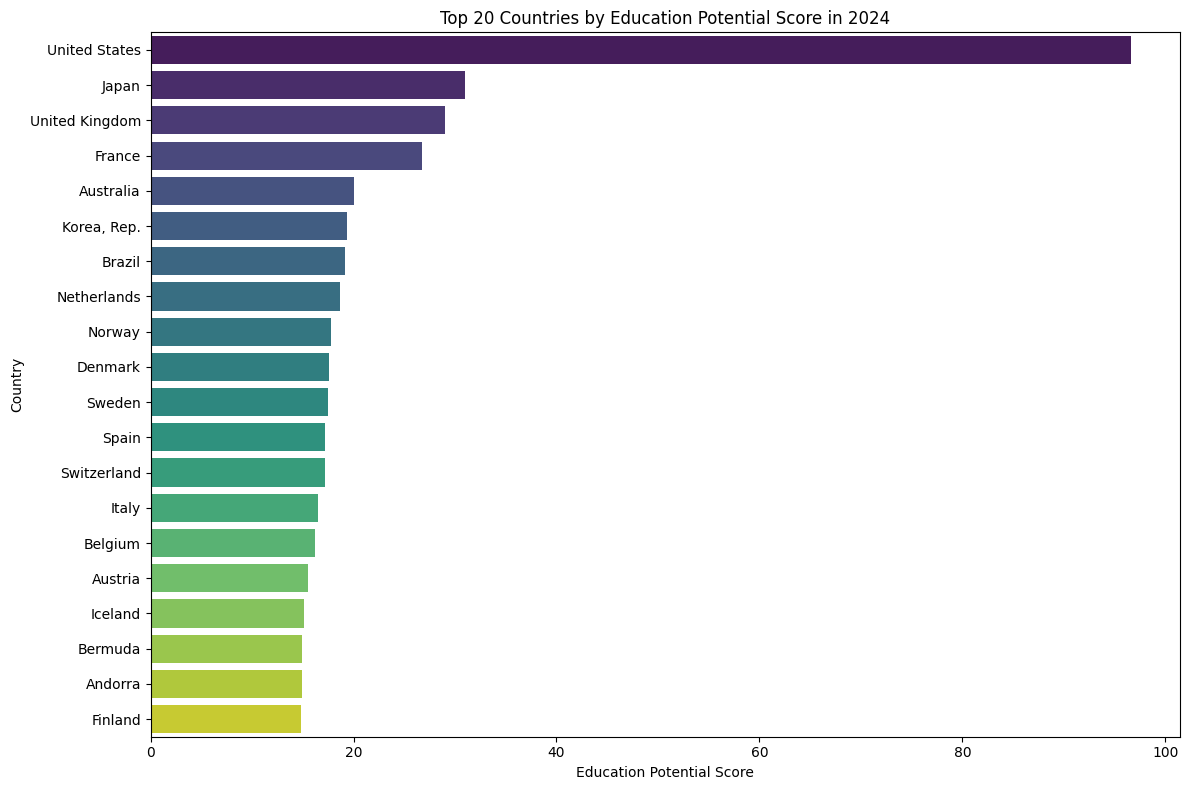

In [8]:
# Find the last year for which scores are available
last_scored_year = reshaped_table['Year'].max()

print(f"Analyzing the last year for which scores are available: {last_scored_year}")

# Filter the table for the last scored year
last_year_data = reshaped_table[reshaped_table['Year'] == last_scored_year].copy()

# Sort by Education Potential Score and take the top 20
top_countries_last_year = last_year_data.sort_values(by='Education Potential Score', ascending=False).head(20)

# Display the top 20 countries for the last scored year
print(f"\nTop 20 Countries by Education Potential Score in {last_scored_year}:")
display(top_countries_last_year)

# Create a bar graph for the top 20 countries in the last scored year
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Education Potential Score',
    y='Country Name',
    data=top_countries_last_year,
    palette='viridis' # Using 'viridis' palette for a color gradient
)

plt.title(f'Top 20 Countries by Education Potential Score in {last_scored_year}')
plt.xlabel('Education Potential Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

C:\Users\shahu\AppData\Local\Temp\ipykernel_30856\617851980.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


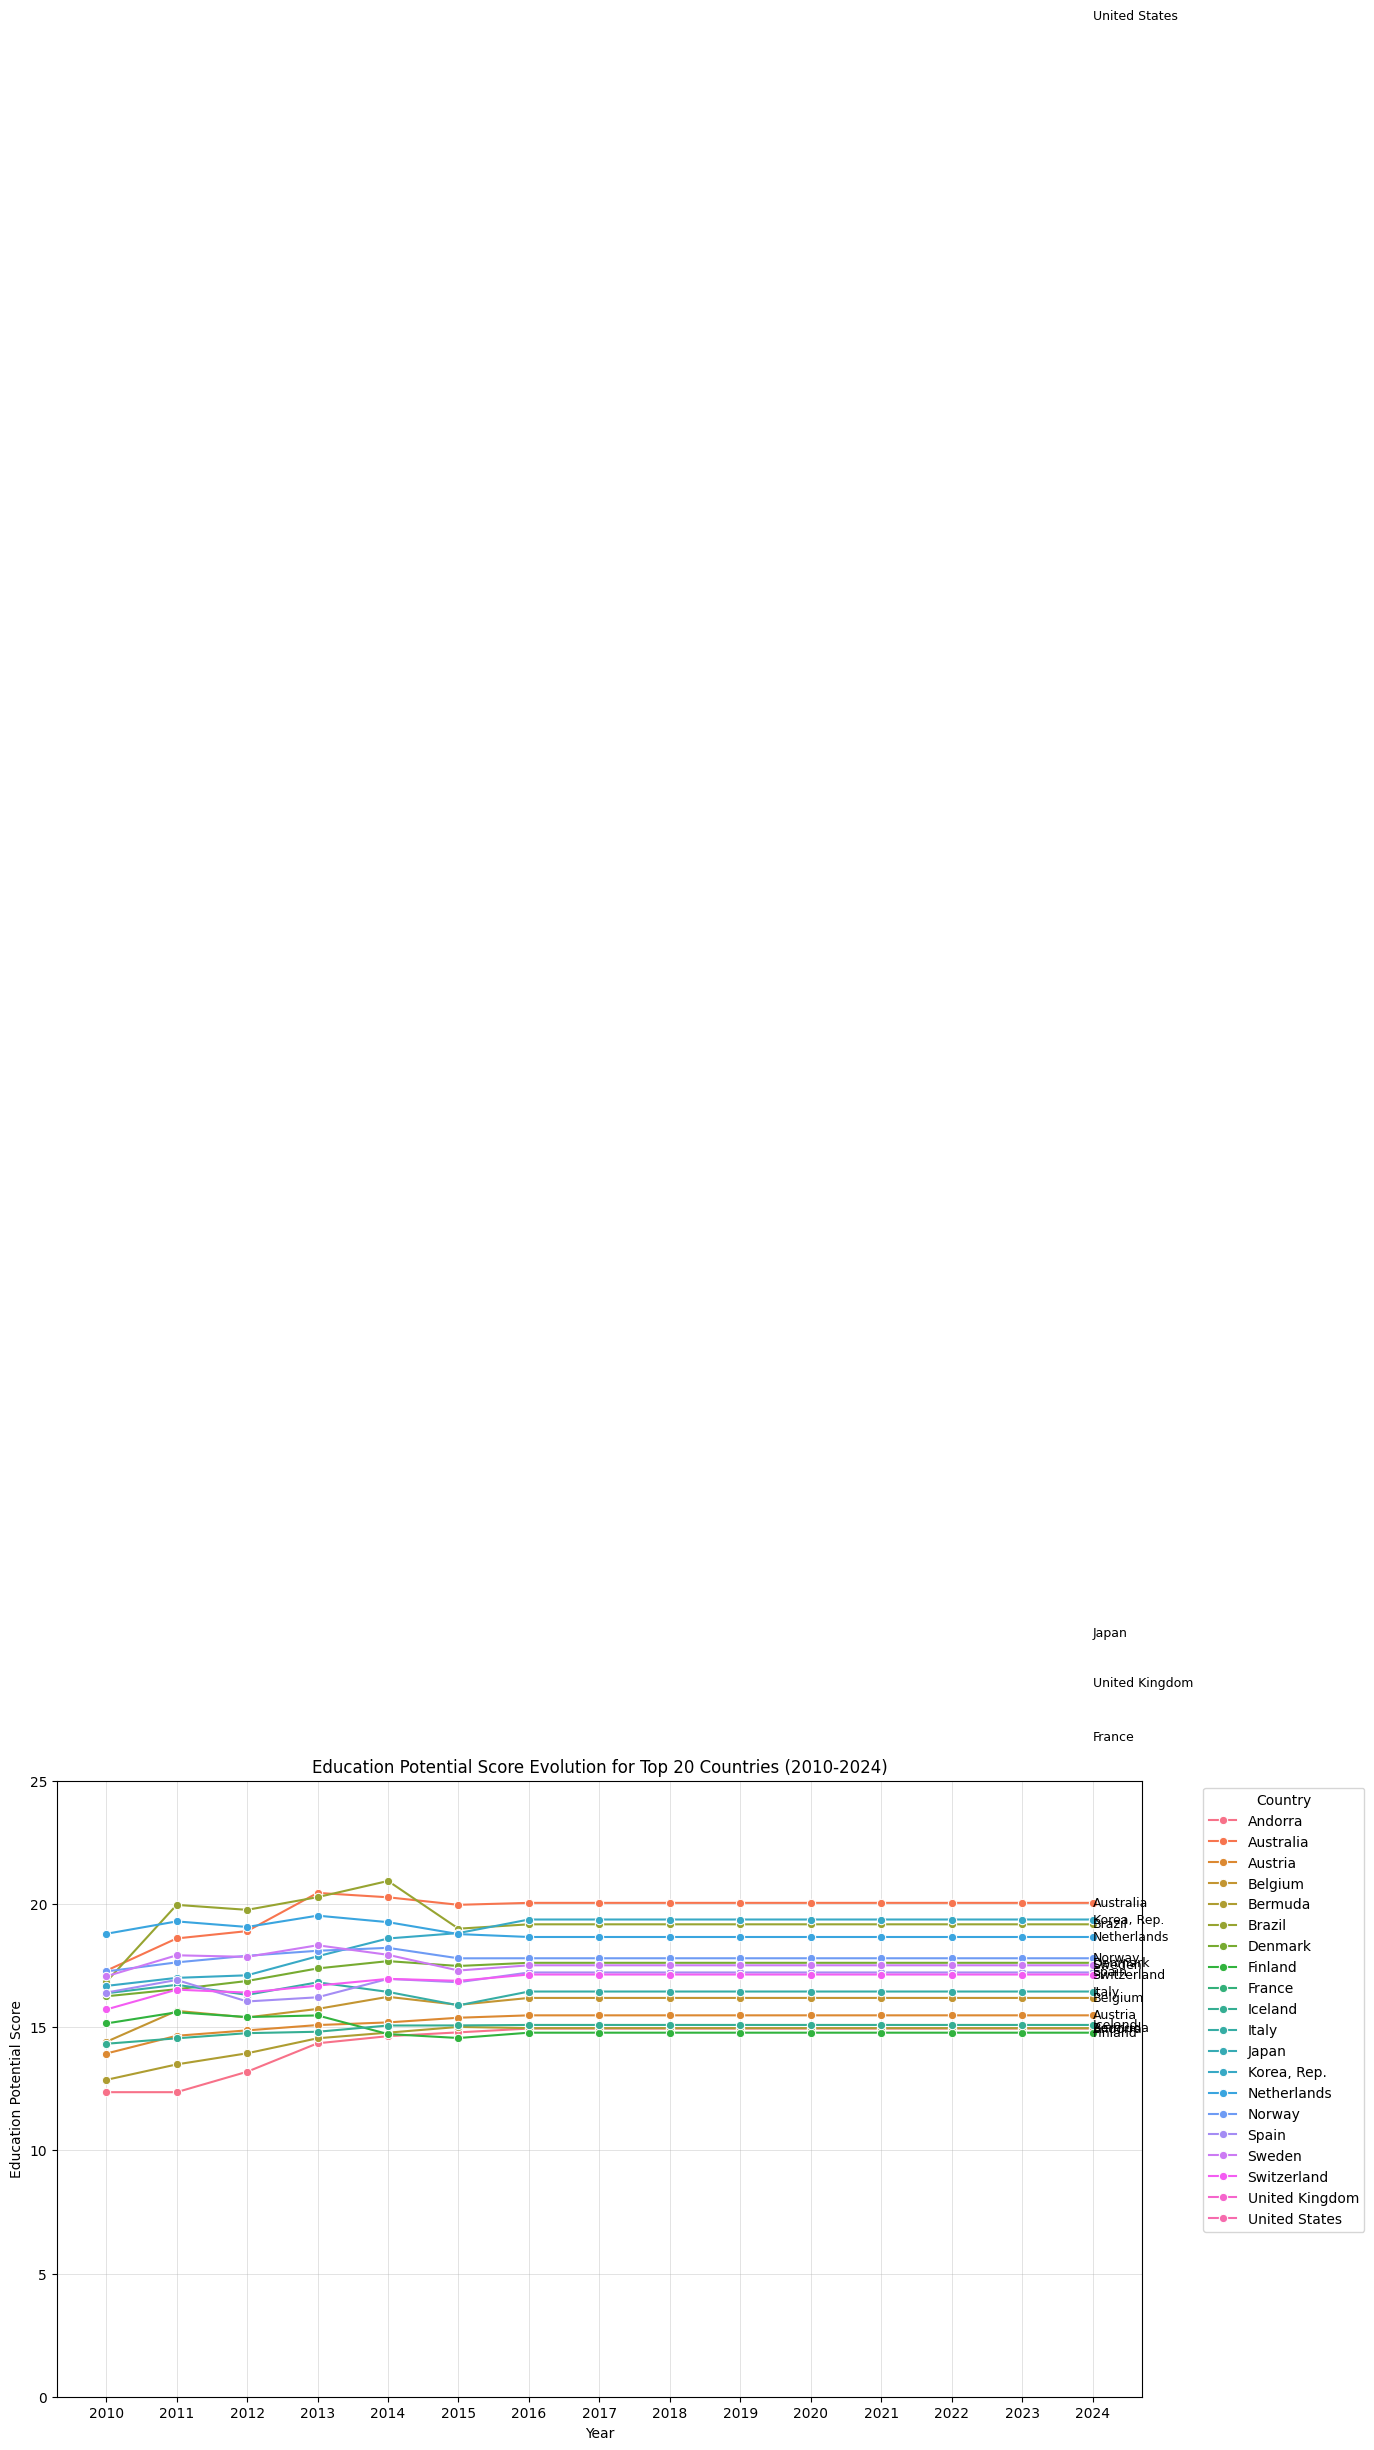

In [9]:
# Filter for the top 20 countries based on the last available year's score
top_20_country_codes = top_countries_last_year['Country Code'].tolist()
top_countries_over_time = reshaped_table[reshaped_table['Country Code'].isin(top_20_country_codes)].copy()

# Create a line plot for the top 20 countries over time
plt.figure(figsize=(14, 8))
ax = sns.lineplot(
    data=top_countries_over_time,
    x='Year',
    y='Education Potential Score',
    hue='Country Name', # Use 'Country Name' to differentiate lines by country
    marker='o' # Add markers to the data points
)

# Add country names as labels on the lines (at the last data point)
for country in top_20_country_codes:
    country_data = top_countries_over_time[top_countries_over_time['Country Code'] == country]
    last_year_data = country_data[country_data['Year'] == country_data['Year'].max()]
    if not last_year_data.empty:
        x = last_year_data['Year'].iloc[0]
        y = last_year_data['Education Potential Score'].iloc[0]
        country_name = last_year_data['Country Name'].iloc[0]
        ax.text(x, y, country_name, fontsize=9, ha='left', va='center')

plt.title('Education Potential Score Evolution for Top 20 Countries (2010-2024)')
plt.xlabel('Year')
plt.ylabel('Education Potential Score')
plt.ylim(0, 25) # Enlarge the y-axis from 0 to 25
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside the plot
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.5) # Make the grid lines smaller and less prominent
plt.tight_layout()
plt.show()

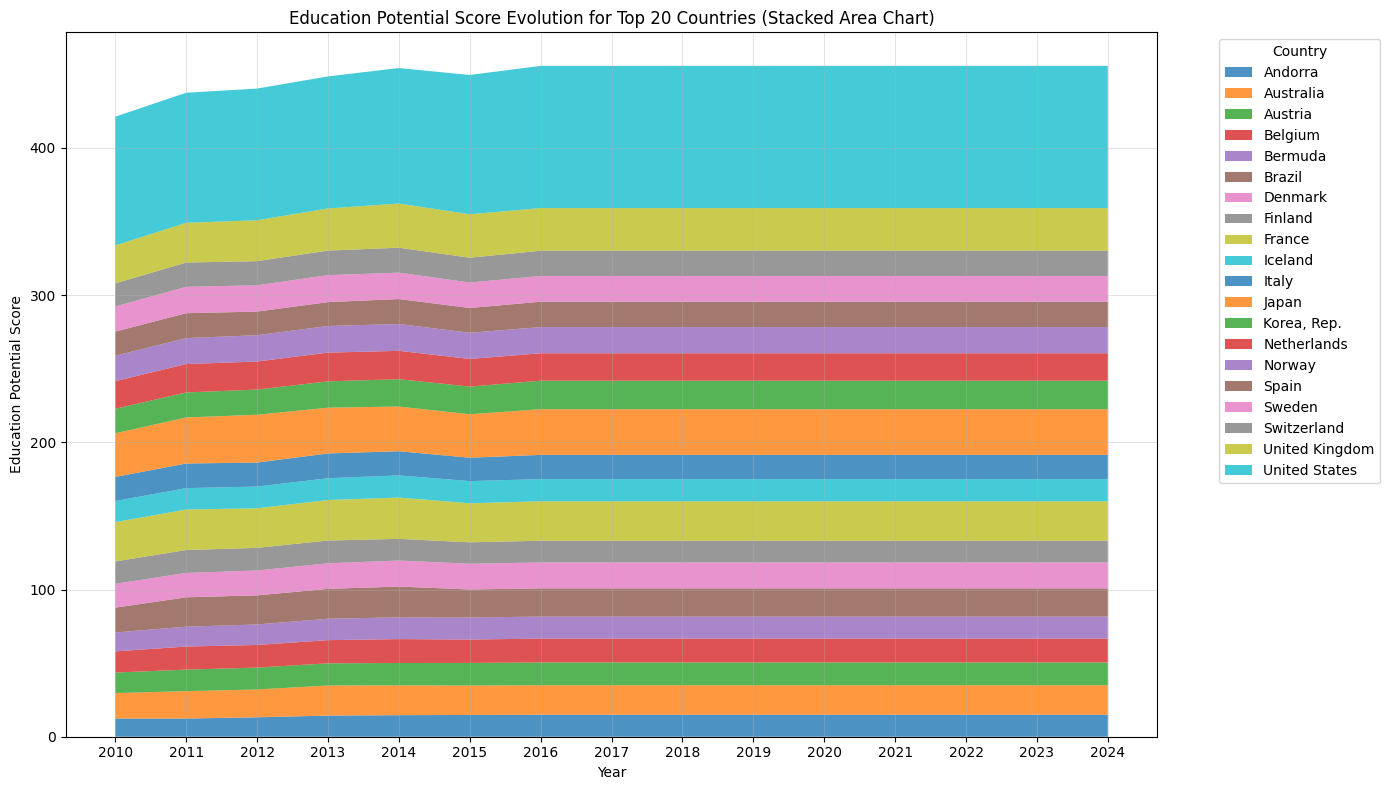

In [10]:
# Create a stacked area chart for the top 20 countries over time
plt.figure(figsize=(14, 8))
plt.stackplot(
    top_countries_over_time.pivot(index='Year', columns='Country Name', values='Education Potential Score').index,
    top_countries_over_time.pivot(index='Year', columns='Country Name', values='Education Potential Score').T.values,
    labels=top_countries_over_time['Country Name'].unique(),
    alpha=0.8
)

plt.title('Education Potential Score Evolution for Top 20 Countries (Stacked Area Chart)')
plt.xlabel('Year')
plt.ylabel('Education Potential Score')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

---

## Conclusion

This analysis successfully identified the **top 20 countries** with the highest education investment potential using World Bank EdStats data. The Education Potential Score combines government expenditure, enrolment figures, GDP, and internet penetration into a single composite metric.

These results can guide Academy's international expansion strategy by highlighting markets where demand for online education is likely to be strongest.